In [69]:
import json

import colorcet
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis, plot_rect, plot_arc

In [91]:
#task_id = "1-static_loops"
#task_id = "2-static_loops_crossable"
task_id = "9-loop_capture_persistent"
config_id = 2

with open(f"{task_id}/_configs/config-{config_id}.json") as file:
    config = json.load(file)

In [92]:
chain, = config["chains"]

chain_length = chain["length"]

enhancer_intervals = []
for feature in chain["association_features"]:
    match feature:
        case {"site": {"start": start, "end": end}}:
            enhancer_intervals.append((start, end))

gene_intervals = []
gene_directions = []
for track in chain["loop_capture_tracks"]:
    match track:
        case {"start": tss, "end": tes}:
            if tss < tes:
                gene_intervals.append((tss, tes))
                gene_directions.append(+1)
            else:
                gene_intervals.append((tes, tss))
                gene_directions.append(-1)

loops = []
for loop in chain["static_loops"]:
    match loop:
        case {"pair": [i, j]}:
            loops.append((i, j))

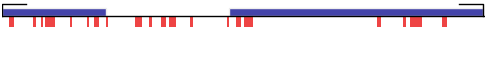

In [93]:
with_genes = True

loop_height_scale = 0.07
loop_height_exponent = 0.7
loop_style = dict(linewidth=0.4, color="black")

fig, ax = plt.subplots(figsize=(2.5, 0.4))

if with_genes:
    for (start, end), strand in zip(gene_intervals, gene_directions):
        plot_rect(ax, start, 0.5, end, 0.9, facecolor="#44a", edgecolor="#eee", zorder=1)

        if strand == +1:
            tss = start
        else:
            tss = end
        x = [tss, tss, tss + 10 * strand]
        y = [0.5, 1.1, 1.1]
        ax.plot(x, y, color="k", zorder=2)

for start, end in enhancer_intervals:
    plot_rect(ax, start, 0, end, 0.5, facecolor="#e44", edgecolor="none", zorder=1)

for i, j in loops:
    x = (i + j) / 2
    y = -0.1
    w = j - i
    h = loop_height_scale * w**loop_height_exponent
    plot_arc(ax, x, y, w, h, theta1=180, theta2=360, **loop_style)

ax.plot([0, chain_length], [0.5, 0.5], color="k", zorder=2)

ax.set_xlim(0, chain_length)
ax.set_ylim(-1.8, 1.2)

set_axis(ax, "none")

fig.savefig(f"_figs/Chromatin-{task_id}-{config_id}.svg")

pass